<div style="width: 100%; background-color: rgb(11,94,132); border: 3px solid #666666; text-align: center; color:rgb(248, 248, 248); border-radius:6px; padding: 10px 0 8px 0;">
    <h1 style="color:rgb(255,255,255);font-weight: bold; margin-bottom: 8px;">🏀 NBA Players Performance 🏀</h1>
    <span style="font-size: 18px; font-style: italic;">Machine Learning | TTFL(Fantasy) points Prediction</span>
</div>


<div style="width: 100%; background-color: rgb(11, 94, 132); color: white; padding: 5px; border: 3px solid #666666; margin-bottom: 5px;border-radius:5px;">
    <h3 style="color: #161616;">Introduction</h3>
<span>This notebook focuses on analyzing NBA player performance data and projecting fantasy points using machine learning techniques. 
TTFL is a french popular fantasy basketball game where participants have to pick each day one NBA player to score the most fantasy points based on their real-life performance.
The Fantasy points are calculated based on various in-game statistics such as points scored, assists, rebounds, steals, blocks, turnovers, and shooting efficiency.
The goal is to build predictive models that can accurately forecast a player's fantasy points in upcoming games based on historical performance data and other relevant features.</span>
<br>
<br>
<h4>The workflow includes:</h4>

1. **Data Loading**:
    - Import and inspect datasets containing NBA box scores, game details, and player statistics.
    - Merge datasets as needed for analysis.

2.  **Data Exploration (EDA) and Cleaning**:
    - Perform exploratory data analysis (EDA) to understand the structure and distribution of the data.
    - Analyze player performance metrics such as points, assists, rebounds, and shooting percentages.
    - Visualize data distributions and correlations between features.

3. **Preprocessing the data**:
    - Prepare the Dataframe: Handle missing values and clean the datasets to ensure consistency.
    - Add some features
    - Derive Per-36-Minute and Per-Possession Rates
    - Scale Features (normalize)

4. **Model Training & Evaluation**:
    - Prepare data for machine learning by selecting relevant features.
    - Modeling: 
        - XGBboost : Extreme Gradient Boosting
        - LightGBM : Light Gradient-Boosting Machine
        - RandomForestRegressor : Classifying decision trees 
    - Train and evaluate models to predict player statistics for future games.
    - Choose the most performant model
    - Visual Comparison of Predicted vs. Actual Points
    - Save the Model


This notebook serves as a comprehensive guide for analyzing NBA data and leveraging machine learning to gain actionable insights into player performance.


In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from common.io_utils import load_data, BoxscoreFileName, AdvancedBoxscoreFileName, PlayersFileName
from common.feature_engineering import merge_data, preprocess_data
from src.targets.fantasy_points import compute_fantasy_points

# Set plot style
sns.set_style("whitegrid")

## 1. Load and Preprocess Data

In [3]:
# Load data 
boxscore_df = pd.read_csv('../../databases/nba_boxscore_basic.csv', low_memory=False)
advanced_boxscore = pd.read_csv('../../databases/nba_boxscore_advanced.csv', low_memory=False)
players_df = pd.read_csv('../../databases/nba_players_df.csv')
nba_teams_df = pd.read_csv('../../databases/nba_teams_df.csv')
print("Data loaded successfully.")


# Merge and preprocess
df = merge_data(boxscore_df, advanced_boxscore, players_df)
df = preprocess_data(df)

# Compute Fantasy Points
df = compute_fantasy_points(df)

print(f"Dataset shape: {df.shape}")
df.head()
# Check type for each column
df.dtypes

Data loaded successfully.
Dataset shape: (39012, 61)


gameId              int64
teamId              int64
teamTricode        object
personId            int64
playerSlug         object
                   ...   
season              int32
is_home              bool
opponent          float64
rest_days         float64
fantasy_points      int64
Length: 61, dtype: object

## 2. Distribution Analysis

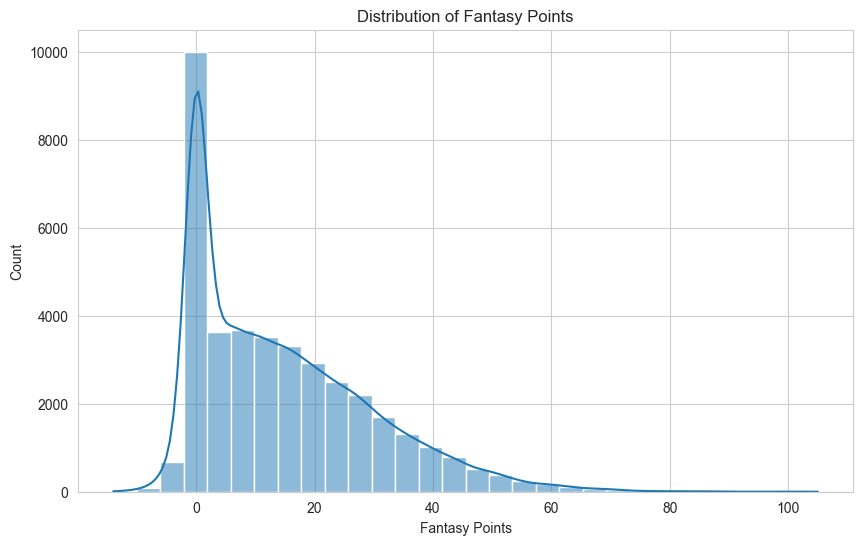

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['fantasy_points'], bins=30, kde=True)
plt.title('Distribution of Fantasy Points')
plt.xlabel('Fantasy Points')
plt.ylabel('Count')
plt.show()

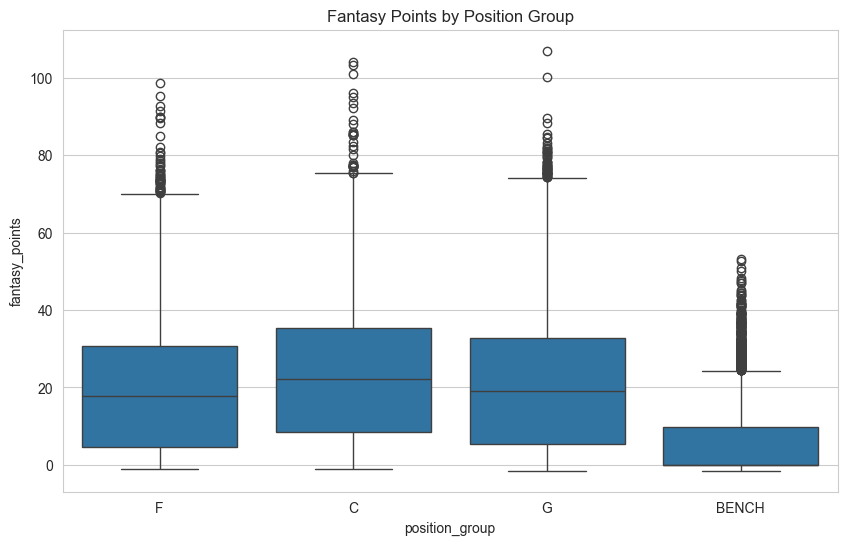

In [27]:
# By Position
plt.figure(figsize=(10, 6))
sns.boxplot(x='position_group', y='fantasy_points', data=df)
plt.title('Fantasy Points by Position Group')
plt.show()

C:\Users\aureb\AppData\Local\Temp\ipykernel_43620\758345835.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fantasy_points', y='display_first_last', data=top_players, palette='viridis')


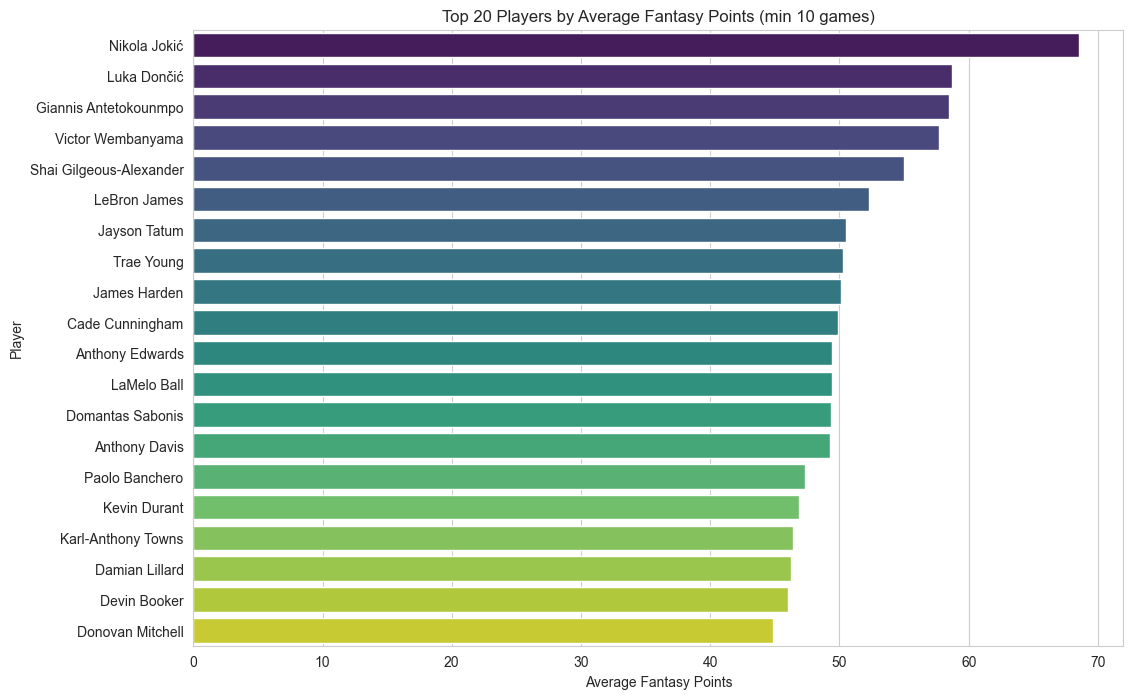

In [30]:
# Top 20 Players by Average Fantasy Points (min 10 games)
player_avg = df.groupby('personId').agg({
    'fantasy_points': 'mean',
    'gameId': 'count',
    'points': 'mean',
    'reboundsTotal': 'mean',
    'assists': 'mean'
}).reset_index()

# Filter min 10 games
player_avg = player_avg[player_avg['gameId'] >= 10]

# Merge with player names
players_df['display_first_last'] = players_df['player_first_name'] + ' ' + players_df['player_last_name']
top_players = player_avg.merge(players_df[['person_id', 'display_first_last']], left_on='personId', right_on='person_id')
top_players = top_players.sort_values('fantasy_points', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x='fantasy_points', y='display_first_last', data=top_players, palette='viridis')
plt.title('Top 20 Players by Average Fantasy Points (min 10 games)')
plt.xlabel('Average Fantasy Points')
plt.ylabel('Player')
plt.show()


## 3. Correlation Analysis

fantasy_points                  1.000000
points                          0.938080
fieldGoalsMade                  0.920493
fieldGoalsAttempted             0.901168
possessions                     0.870929
minutes                         0.869003
reboundsTotal                   0.736271
reboundsDefensive               0.736205
assists                         0.725775
threePointersAttempted          0.699165
threePointersMade               0.674131
usagePercentage                 0.669949
estimatedUsagePercentage        0.669949
freeThrowsAttempted             0.651516
freeThrowsMade                  0.639549
trueShootingPercentage          0.603305
offensiveRating                 0.596846
estimatedOffensiveRating        0.596846
freeThrowsPercentage            0.587338
fieldGoalsPercentage            0.583260
effectiveFieldGoalPercentage    0.580995
turnovers                       0.556971
assistToTurnover                0.527051
Name: fantasy_points, dtype: float64


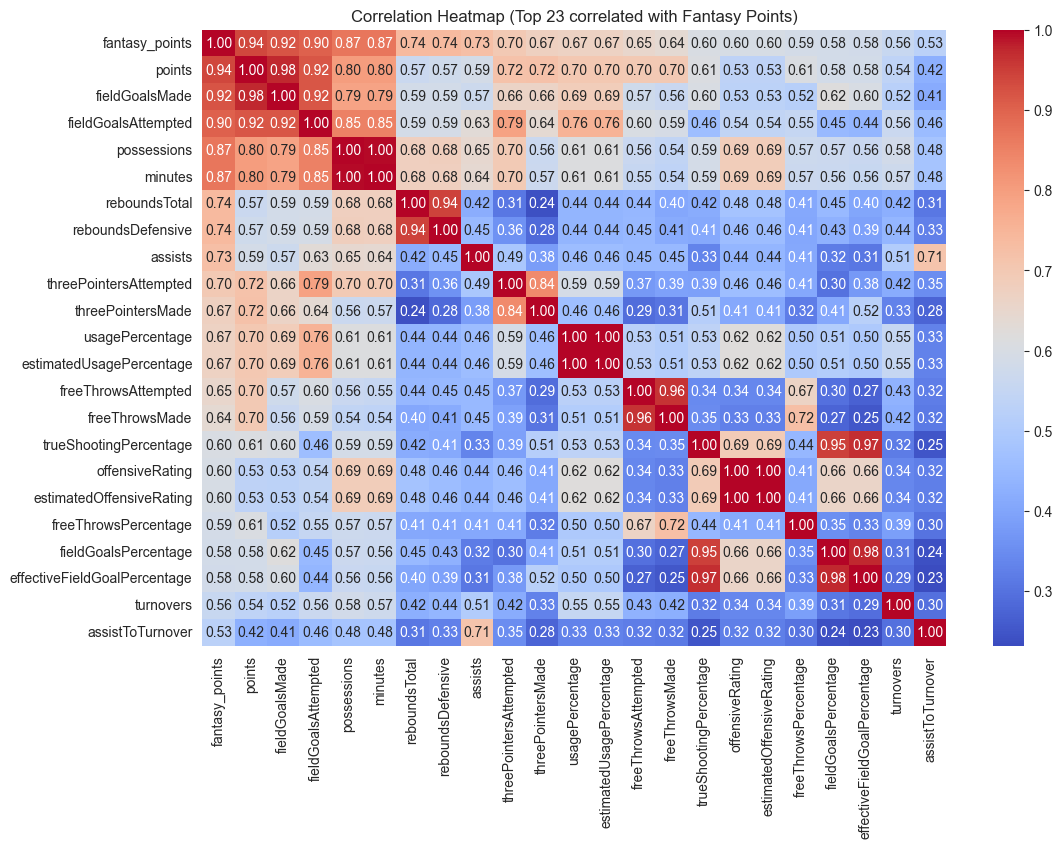

In [31]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

# Correlation with Fantasy Points
fp_corr = corr['fantasy_points'].sort_values(ascending=False).head(23)
print(fp_corr)

plt.figure(figsize=(12, 8))
sns.heatmap(df[fp_corr.index].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Top 23 correlated with Fantasy Points)')
plt.show()

C:\Users\aureb\AppData\Local\Temp\ipykernel_43620\3509833595.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=component_corr.values, y=component_corr.index, palette='coolwarm')


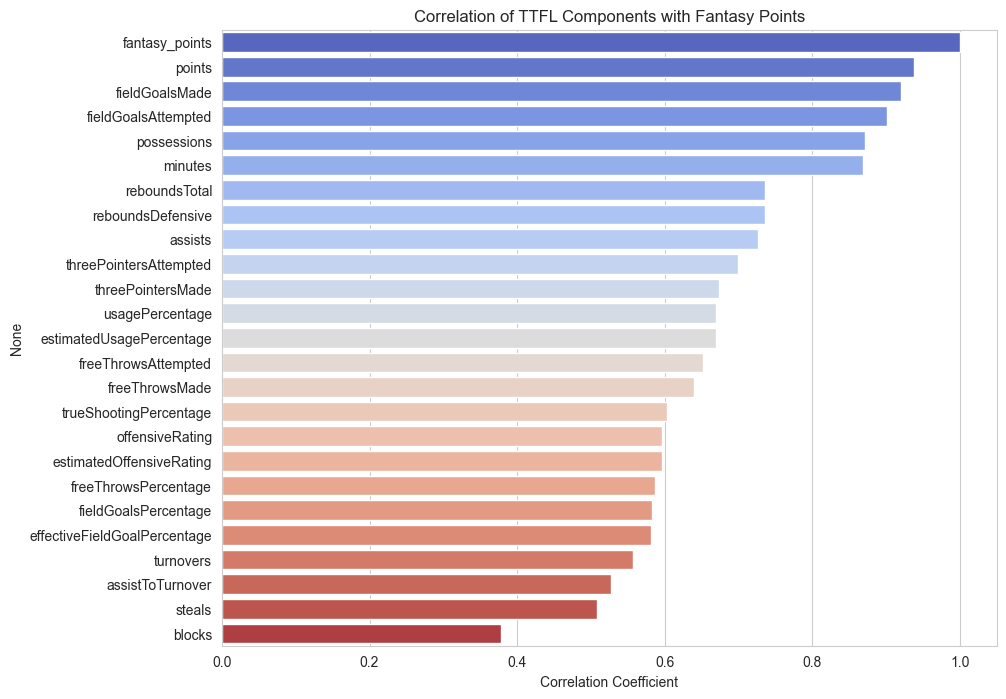

In [36]:
# Correlation of specific TTFL components
ttfl_components = ['points', 'fieldGoalsMade', 'fieldGoalsAttempted', 'possessions', 'minutes', 
                   'reboundsTotal', 'reboundsDefensive', 'assists', 'threePointersAttempted',
                   'threePointersMade', 'usagePercentage', 'estimatedUsagePercentage', 'freeThrowsAttempted',
                   'freeThrowsMade', 'trueShootingPercentage', 'offensiveRating', 'estimatedOffensiveRating',
                   'freeThrowsPercentage', 'fieldGoalsPercentage', 'effectiveFieldGoalPercentage', 'turnovers',
                   'assistToTurnover', 'steals', 'blocks']

plt.figure(figsize=(10, 8))
component_corr = df[ttfl_components + ['fantasy_points']].corr()['fantasy_points'].sort_values(ascending=False)
sns.barplot(x=component_corr.values, y=component_corr.index, palette='coolwarm')
plt.title('Correlation of TTFL Components with Fantasy Points')
plt.xlabel('Correlation Coefficient')
plt.show()

## 4. Feature Importance (Baseline Model)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002966 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2396
[LightGBM] [Info] Number of data points in the train set: 28293, number of used features: 24
[LightGBM] [Info] Start training from score 18.856113


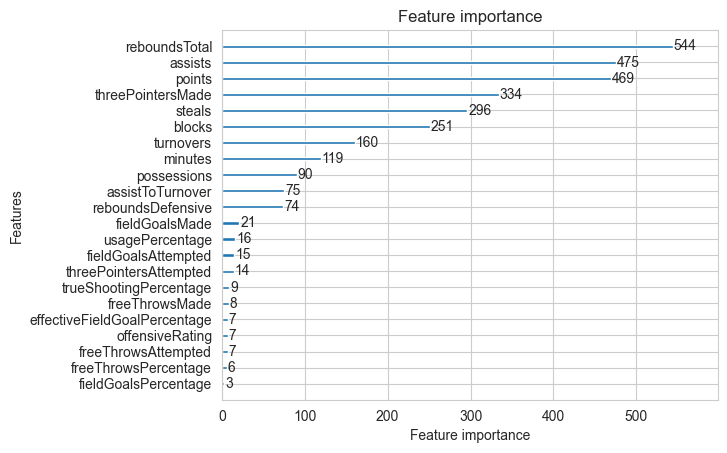


Feature Importance Table:
                     feature  importance
               reboundsTotal         544
                     assists         475
                      points         469
           threePointersMade         334
                      steals         296
                      blocks         251
                   turnovers         160
                     minutes         119
                 possessions          90
            assistToTurnover          75
           reboundsDefensive          74
              fieldGoalsMade          21
             usagePercentage          16
         fieldGoalsAttempted          15
      threePointersAttempted          14
      trueShootingPercentage           9
              freeThrowsMade           8
effectiveFieldGoalPercentage           7
             offensiveRating           7
         freeThrowsAttempted           7
        freeThrowsPercentage           6
        fieldGoalsPercentage           3
    estimatedOffensiveRating  

In [39]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split

# Prepare features
features = ttfl_components
target = 'fantasy_points'

# Drop NaNs
df_model = df.dropna(subset=features + [target])

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor()
model.fit(X_train, y_train)

# Plot importance
import lightgbm as lgb
lgb.plot_importance(model, max_num_features=25)
plt.show()

# Get feature importance as a DataFrame
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance Table:")
print(feature_importance_df.to_string(index=False))

## 5. Diagnose — Engineering Features Incorrectly Normalised

**Bug:** `normalize_features()` iterates over **all** `key_stats`, including the three opponent-defensive
aggregates (`avg_fantasy_points_opp_position_last_10/20/all`).
Those are team-level aggregates and should never be divided by an individual player's minutes.

```python
# common/feature_engineering.py  (lines 203-214)
for stat in key_stats:                        # ← includes engineering stats
    per36 = f"{stat}_per36"
    df[per36] = df[stat] / df["minutes"] * 36  # ← nonsense for aggregates
```

Result: `avg_fp_opp_pos_last_10_per36 = avg_fp_opp_pos_last_10 / player_minutes * 36`
A player who plays 36 min vs 12 min will have *the exact same defensive quality feature
look 3× different* — purely based on his playing time, corrupting one of the most informative signals.

In [5]:
# ── Reproduce the bug ──────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from common.feature_engineering import (
    merge_data, preprocess_data, create_historical_features,
    normalize_features, compute_rolling_stats, get_feature_cols
)
from src.targets.fantasy_points import compute_fantasy_points
from common.constants import key_stats_fantasy

# Load data
box     = pd.read_csv('../../databases/nba_boxscore_basic.csv', low_memory=False)
adv     = pd.read_csv('../../databases/nba_boxscore_advanced.csv', low_memory=False)
players = pd.read_csv('../../databases/nba_players_df.csv')

df = merge_data(box, adv, players)
df = preprocess_data(df)
df = compute_fantasy_points(df)
df = create_historical_features(df, target_col='fantasy_points')

# Apply current (buggy) normalisation
df_buggy = normalize_features(df.copy(), key_stats_fantasy)

eng_stat  = 'avg_fantasy_points_opp_position_last_10'
col_buggy = f'{eng_stat}_per36'

print("Engineering stat — raw values (sample):")
print(df_buggy[eng_stat].describe())
print(f"\n{col_buggy} — after /minutes*36 (should be SAME value for same matchup, not player-dependent):")
print(df_buggy[col_buggy].describe())
corr = df_buggy['minutes'].corr(df_buggy[col_buggy])
print(f"\nCorrelation with minutes: {corr:.3f}")
print("→ High minutes correlation means this feature encodes playing time, NOT defensive quality!")


Engineering stat — raw values (sample):
count    39012.000000
mean        24.383247
std          4.854477
min          0.000000
25%         21.750000
50%         24.350000
75%         27.100000
max         68.000000
Name: avg_fantasy_points_opp_position_last_10, dtype: float64

avg_fantasy_points_opp_position_last_10_per36 — after /minutes*36 (should be SAME value for same matchup, not player-dependent):
count    3.895800e+04
mean              inf
std               NaN
min      0.000000e+00
25%      2.887528e+01
50%      4.240531e+01
75%      1.292605e+02
max               inf
Name: avg_fantasy_points_opp_position_last_10_per36, dtype: float64

Correlation with minutes: nan
→ High minutes correlation means this feature encodes playing time, NOT defensive quality!


In [6]:
# ── The fix: normalise only raw stats ──────────────────────────────────────
def normalize_features_fixed(df: pd.DataFrame, key_stats: dict) -> pd.DataFrame:
    """
    Fixed: only RAW stats get per36/per_poss treatment.
    Engineering (opponent-defensive) stats are kept as-is.
    """
    raw_stats = {k for k, v in key_stats.items() if 'raw'         in v.lower()}
    eng_stats = {k for k, v in key_stats.items() if 'engineering' in v.lower()}

    for stat in raw_stats:
        if stat in df.columns:
            df[f'{stat}_per36']    = df[stat] / df['minutes'] * 36
            df[f'{stat}_per_poss'] = df[stat] / df['possessions']

    # Engineering stats: expose them directly under the _per36/_per_poss names
    # so get_feature_cols() references still resolve, but no minutes distortion.
    for stat in eng_stats:
        if stat in df.columns:
            df[f'{stat}_per36']    = df[stat]
            df[f'{stat}_per_poss'] = df[stat]

    return df

df_fixed_norm = normalize_features_fixed(df.copy(), key_stats_fantasy)

corr_fixed = df_fixed_norm['minutes'].corr(df_fixed_norm[f'{eng_stat}_per36'])
print(f"Fixed — correlation of {eng_stat}_per36 with minutes: {corr_fixed:.3f}")
print("(Should be low/near-zero — it now encodes matchup quality, not playing time)")


Fixed — correlation of avg_fantasy_points_opp_position_last_10_per36 with minutes: 0.012
(Should be low/near-zero — it now encodes matchup quality, not playing time)


## 6. Diagnose — `possessions_per_poss` is a Constant Feature (Always 1.0)

**Bug:** `possessions` is listed in `key_stats_fantasy` as a raw stat.
`normalize_features` computes `possessions_per_poss = possessions / possessions = 1.0` for every row.
After rolling, all `possessions_per_poss_rolling_{3,7,15,30}` features are also 1.0.

These 4 constant features consume feature-importance budget and add noise to the model.

In [7]:
# Verify the constant-feature bug
df_check = normalize_features(df.copy(), key_stats_fantasy)

poss_ppp = 'possessions_per_poss'
if poss_ppp in df_check.columns:
    unique_vals = df_check[poss_ppp].dropna().unique()
    print(f'{poss_ppp} — unique values: {unique_vals[:8]}')
    print(f'All 1.0? {(df_check[poss_ppp].dropna().round(6) == 1.0).all()}')
else:
    print(f'{poss_ppp} column not present')

# Confirm rolling features are also constant
df_rolled = compute_rolling_stats(df_check, key_stats_fantasy, windows=[3,7,15,30])
rolling_cols = [c for c in df_rolled.columns if 'possessions_per_poss_rolling' in c]
print(f'\nRolling possessions_per_poss cols: {rolling_cols}')
for col in rolling_cols:
    all_one = (df_rolled[col].dropna().round(6) == 1.0).all()
    print(f'  {col}: all 1.0 = {all_one}')


possessions_per_poss — unique values: [1.]
All 1.0? True

Rolling possessions_per_poss cols: ['possessions_per_poss_rolling_3', 'possessions_per_poss_rolling_7', 'possessions_per_poss_rolling_15', 'possessions_per_poss_rolling_30']
  possessions_per_poss_rolling_3: all 1.0 = True
  possessions_per_poss_rolling_7: all 1.0 = True
  possessions_per_poss_rolling_15: all 1.0 = True
  possessions_per_poss_rolling_30: all 1.0 = True


In [8]:
# Check feature importance of those constant columns in the baseline model
from lightgbm import LGBMRegressor

df_fi = compute_rolling_stats(
    normalize_features(df.copy(), key_stats_fantasy),
    key_stats_fantasy, windows=[3,7,15,30]
).dropna(subset=['fantasy_points'])

feat_baseline = [f for f in get_feature_cols(key_stats_fantasy, rolling_periods=[3,7,15,30])
                 if f in df_fi.columns]
X_fi = df_fi[feat_baseline].replace([np.inf,-np.inf], np.nan).fillna(0)
y_fi = df_fi['fantasy_points']

m_fi = LGBMRegressor(n_estimators=200, verbose=-1, random_state=42)
m_fi.fit(X_fi, y_fi)

fi_df = pd.DataFrame({'feature': feat_baseline,
                       'importance': m_fi.feature_importances_}).sort_values('importance')
poss_fi = fi_df[fi_df['feature'].str.contains('possessions_per_poss')]
print("Feature importance for possessions_per_poss_rolling_* (expect ~0):")
print(poss_fi.to_string(index=False))


Feature importance for possessions_per_poss_rolling_* (expect ~0):
                        feature  importance
 possessions_per_poss_rolling_3           0
possessions_per_poss_rolling_15           0
 possessions_per_poss_rolling_7           0
possessions_per_poss_rolling_30           0


## 7. Diagnose — Encoder Re-fit at Inference (Silent Misalignment Risk)

**Problem:** `encode_categorical_features()` creates a brand-new `OneHotEncoder` and fits it
on the *current* historical data at every prediction run.
As new seasons accumulate, the column order shifts. The `reindex(fill_value=0)` rescue in
`get_final_df` catches explicit mismatches but can silently zero-out valid season columns.

**Fix:** Serialise the fitted encoder inside the model artifact. At inference, reuse it.
Only re-fit when re-training.

In [9]:
from sklearn.preprocessing import OneHotEncoder
from common.constants import categorical_cols_fantasy

# ── Reproduce the drift ───────────────────────────────────────────────────
seasons_train = df[df['season'] <= 2024].copy()
seasons_all   = df.copy()

enc_old = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc_old.fit(seasons_train[categorical_cols_fantasy])

enc_new = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc_new.fit(seasons_all[categorical_cols_fantasy])

cols_old = set(enc_old.get_feature_names_out(categorical_cols_fantasy))
cols_new = set(enc_new.get_feature_names_out(categorical_cols_fantasy))

print(f"Columns only in NEW encoder (seasons added after training): {cols_new - cols_old}")
print(f"Columns only in OLD encoder (seasons no longer in window):  {cols_old - cols_new}")
print(f"\nModel trained on {len(cols_old)} encoded cols;")
print(f"inference feed has {len(cols_new)} encoded cols before reindex.")
print("\n→ Fix: save enc_old in the model pickle, reuse it at inference time.")


Columns only in NEW encoder (seasons added after training): {'season_2025'}
Columns only in OLD encoder (seasons no longer in window):  set()

Model trained on 6 encoded cols;
inference feed has 7 encoded cols before reindex.

→ Fix: save enc_old in the model pickle, reuse it at inference time.


In [10]:
# ── Skeleton: encode_with_saved_encoder() ────────────────────────────────
def encode_with_saved_encoder(
    df: pd.DataFrame,
    categorical_cols: list,
    encoder: OneHotEncoder = None
):
    """
    Training time : pass encoder=None  → fit, return encoder.
    Inference time: pass saved encoder → transform only, no refit.
    """
    if encoder is None:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoded = encoder.fit_transform(df[categorical_cols])
    else:
        encoded = encoder.transform(df[categorical_cols])

    feature_names = encoder.get_feature_names_out(categorical_cols).tolist()
    df = df.drop(categorical_cols, axis=1)
    df = pd.concat(
        [df, pd.DataFrame(encoded, columns=feature_names, index=df.index)], axis=1
    )
    return df, feature_names, encoder

# Training
df_enc_train, enc_feat_names, saved_enc = encode_with_saved_encoder(
    df[df['season'] <= 2024].copy(), categorical_cols_fantasy
)
print(f"Training encoder fitted → {len(enc_feat_names)} columns")

# Inference (reuse same encoder)
df_enc_infer, inf_feat_names, _ = encode_with_saved_encoder(
    df[df['season'] > 2024].copy(), categorical_cols_fantasy, encoder=saved_enc
)
print(f"Inference (same encoder) → {len(inf_feat_names)} columns (handle_unknown=ignore for new seasons)")
print("No column order surprise. New seasons get all-zero encoding automatically.")


Training encoder fitted → 6 columns
Inference (same encoder) → 6 columns (handle_unknown=ignore for new seasons)
No column order surprise. New seasons get all-zero encoding automatically.


## 8. Fix — Quantile Regression to Escape the Prediction Ceiling

**Root cause of the ~48 ceiling:** `objective='regression'` minimises MSE → predicts the
*conditional mean*. Even Jokić's conditional mean is ~45–48.

For TTFL you pick 1 player per night — you want the player with the highest **upside**,
not the highest average.

**Fix:** `objective='quantile', alpha=0.75` or `0.85` predicts the upper quartile/quintile.
A player with a high 75th-percentile score is more likely to deliver a big night.

| Model | Objective | What it predicts |
|-------|-----------|------------------|
| Baseline | `regression` (MSE) | Conditional mean |
| Q75 | `quantile alpha=0.75` | 75th percentile |
| Q85 | `quantile alpha=0.85` | 85th percentile |

In [11]:
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ── Time-based split ─────────────────────────────────────────────────────
df_model = normalize_features(df.copy(), key_stats_fantasy)
df_model = compute_rolling_stats(df_model, key_stats_fantasy, windows=[3,7,15,30])
df_model = df_model.dropna(subset=['fantasy_points']).sort_values('game_date')

feat_list    = get_feature_cols(key_stats_fantasy, rolling_periods=[3,7,15,30])
avail_feats  = [f for f in feat_list if f in df_model.columns]

unique_dates = np.sort(df_model['game_date'].unique())
split_date   = unique_dates[int(0.80 * len(unique_dates))]

train = df_model[df_model['game_date'] <  split_date]
test  = df_model[df_model['game_date'] >= split_date]

X_tr = train[avail_feats].replace([np.inf,-np.inf], np.nan).fillna(0)
y_tr = train['fantasy_points']
X_te = test[avail_feats].replace([np.inf,-np.inf],  np.nan).fillna(0)
y_te = test['fantasy_points']

print(f"Train: {len(X_tr):,} rows  |  Test: {len(X_te):,} rows  |  Split: {split_date}")


Train: 31,076 rows  |  Test: 7,936 rows  |  Split: 2025-05-27T00:00:00.000000000


In [12]:
# ── Train 3 models ───────────────────────────────────────────────────────
base_params = dict(n_estimators=500, learning_rate=0.05, max_depth=7,
                   num_leaves=63, subsample=0.8, colsample_bytree=0.7,
                   verbose=-1, random_state=42)

m_mean = LGBMRegressor(**base_params, objective='regression')
m_q75  = LGBMRegressor(**base_params, objective='quantile', alpha=0.75)
m_q85  = LGBMRegressor(**base_params, objective='quantile', alpha=0.85)

for m in (m_mean, m_q75, m_q85):
    m.fit(X_tr, y_tr)

pred_mean = m_mean.predict(X_te)
pred_q75  = m_q75.predict(X_te)
pred_q85  = m_q85.predict(X_te)

print("── Prediction ceiling comparison ─────────────────────────────────")
print(f"  {'Model':<22} {'max':>6} {'p95':>6} {'p99':>6} {'MAE':>7}")
print(f"  {'-'*48}")
for label, preds in [('Mean (current prod)', pred_mean),
                      ('Quantile-75',        pred_q75),
                      ('Quantile-85',        pred_q85)]:
    print(f"  {label:<22} {preds.max():>6.1f} {np.percentile(preds,95):>6.1f}"
          f" {np.percentile(preds,99):>6.1f} {mean_absolute_error(y_te,preds):>7.2f}")


── Prediction ceiling comparison ─────────────────────────────────
  Model                     max    p95    p99     MAE
  ------------------------------------------------
  Mean (current prod)      62.3   34.4   42.0    6.50
  Quantile-75              69.4   41.9   50.4    7.39
  Quantile-85              68.6   45.6   53.5    8.92


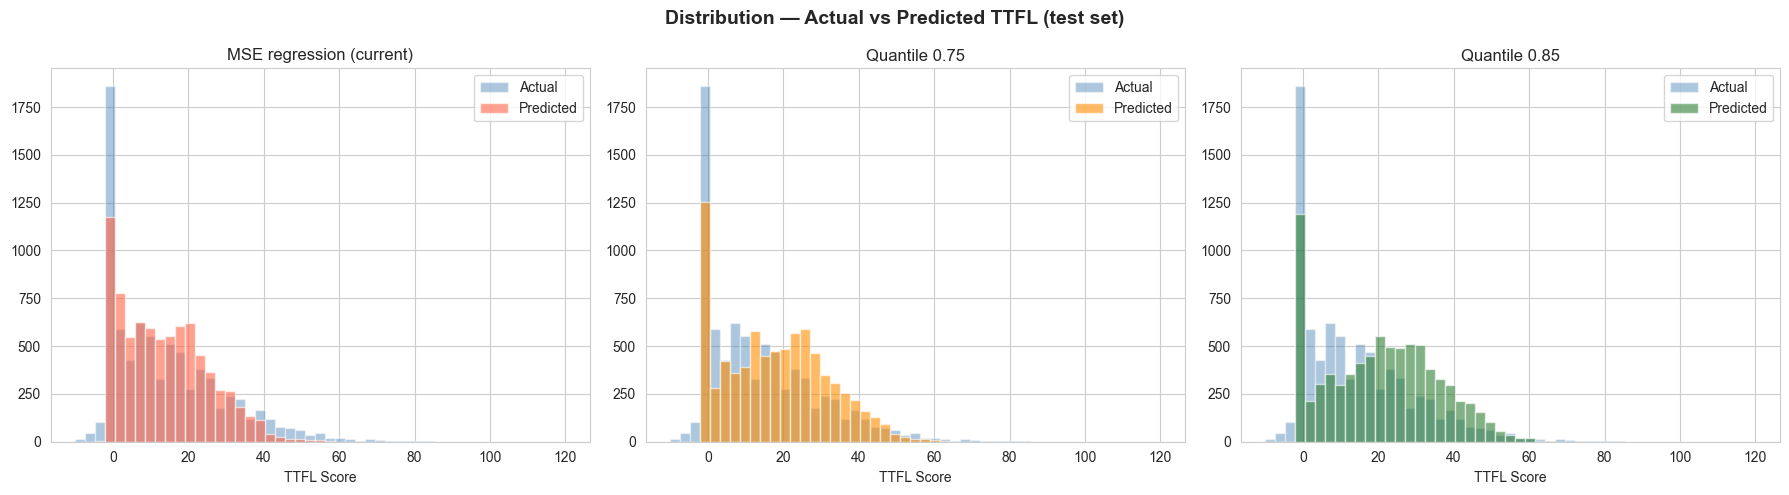


Elite game nights in test set (actual ≥ 60): 68
  Mean  : hit-rate among top-N predictions = 29.4%
  Q75   : hit-rate among top-N predictions = 29.4%
  Q85   : hit-rate among top-N predictions = 23.5%


In [13]:
# ── Distribution: predicted vs actual ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
bins = np.linspace(-10, 120, 50)

for ax, preds, title, color in zip(
    axes,
    [pred_mean, pred_q75, pred_q85],
    ['MSE regression (current)', 'Quantile 0.75', 'Quantile 0.85'],
    ['tomato', 'darkorange', '#2e7d32']
):
    ax.hist(y_te, bins=bins, alpha=0.45, label='Actual',    color='steelblue')
    ax.hist(preds,   bins=bins, alpha=0.60, label='Predicted', color=color)
    ax.set_title(title); ax.set_xlabel('TTFL Score'); ax.legend()

plt.suptitle('Distribution — Actual vs Predicted TTFL (test set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# How many elite nights (≥60) did each model identify in top predictions?
elite_actual = y_te >= 60
print(f"\nElite game nights in test set (actual ≥ 60): {elite_actual.sum()}")
for label, preds in [('Mean  ', pred_mean), ('Q75   ', pred_q75), ('Q85   ', pred_q85)]:
    top_n = np.argsort(preds)[::-1][:int(elite_actual.sum())]
    hit_rate = elite_actual.values[top_n].mean()
    print(f"  {label}: hit-rate among top-N predictions = {hit_rate:.1%}")


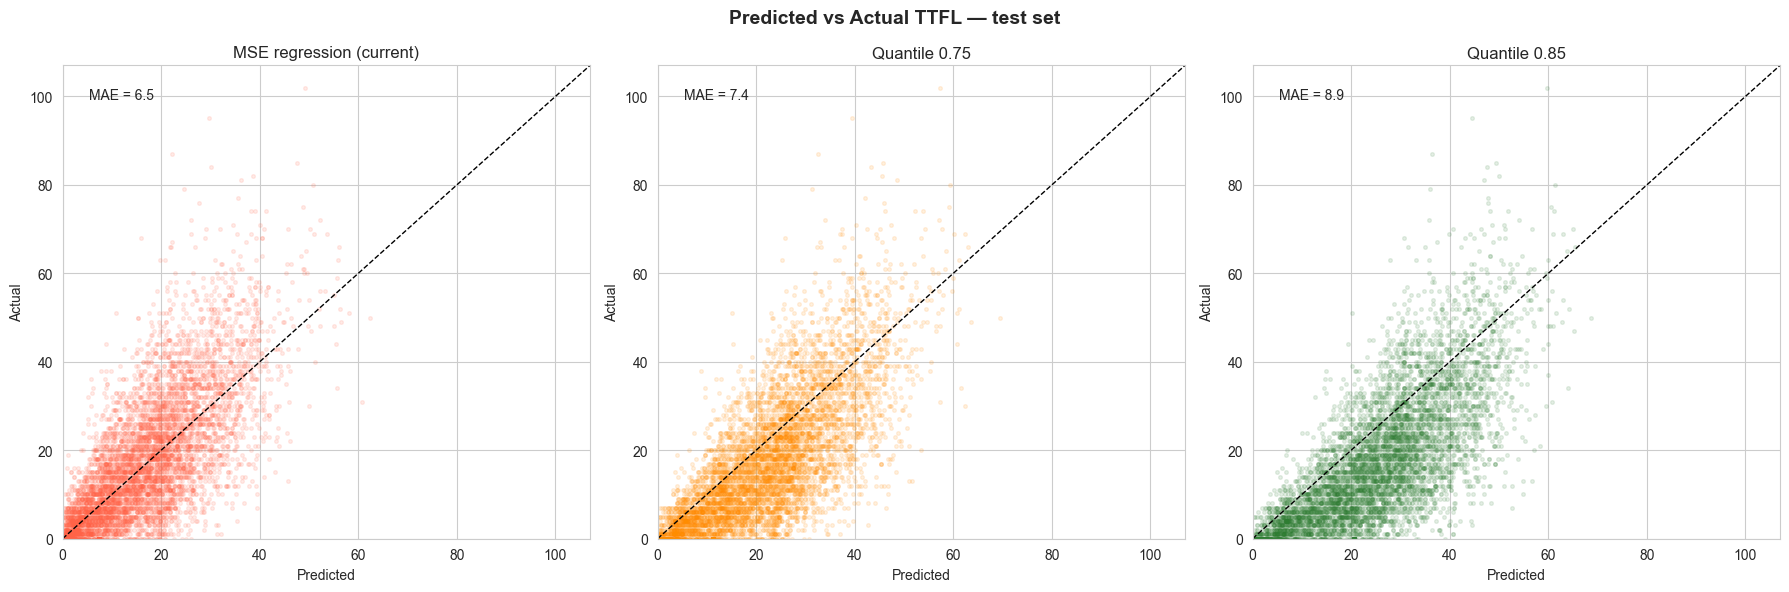

In [14]:
# ── Scatter: predicted vs actual (test set) ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, preds, title, color in zip(
    axes,
    [pred_mean, pred_q75, pred_q85],
    ['MSE regression (current)', 'Quantile 0.75', 'Quantile 0.85'],
    ['tomato', 'darkorange', '#2e7d32']
):
    ax.scatter(preds, y_te.values, alpha=0.12, s=7, color=color)
    lim = max(preds.max(), y_te.max()) + 5
    ax.plot([0, lim], [0, lim], 'k--', lw=1, label='Perfect')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title)
    ax.text(0.05, 0.93, f'MAE = {mean_absolute_error(y_te, preds):.1f}',
            transform=ax.transAxes, fontsize=10)

plt.suptitle('Predicted vs Actual TTFL — test set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Full Pipeline — Baseline vs Fixed Model (All Changes Combined)

Combining:
1. Engineering stats not normalised by player minutes  
2. `possessions_per_poss` constant feature excluded  
3. Quantile-0.75 objective  
4. Encoder reused (consistent fit on training window)

In [15]:
# ── Helper: fixed feature columns ───────────────────────────────────────
def get_feature_cols_fixed(key_stats: dict, rolling_periods: list) -> list:
    """
    Fixed get_feature_cols:
    - Raw stats only get per36/per_poss rolling treatment
    - Engineering stats are included raw (the stat name itself, not per36/per_poss)
    - possessions excluded from per_poss rolling
    """
    raw_stats = [k for k, v in key_stats.items()
                 if 'raw' in v.lower() and k != 'possessions']
    eng_stats = [k for k, v in key_stats.items() if 'engineering' in v.lower()]

    feature_cols = []
    for window in rolling_periods:
        for stat in raw_stats:
            feature_cols.append(f'{stat}_per36_rolling_{window}')
        for stat in raw_stats:
            feature_cols.append(f'{stat}_per_poss_rolling_{window}')
        for stat in raw_stats:
            feature_cols.append(f'{stat}_rolling_{window}')
    # possessions raw rolling (per36 only, no per_poss)
    for window in rolling_periods:
        feature_cols.append(f'possessions_per36_rolling_{window}')
        feature_cols.append(f'possessions_rolling_{window}')
    # Engineering stats: raw signal
    for stat in eng_stats:
        feature_cols.append(stat)
    feature_cols.append('rest_days')
    return feature_cols


# ── BASELINE pipeline (current prod) ─────────────────────────────────────
df_b = normalize_features(df.copy(), key_stats_fantasy)
df_b = compute_rolling_stats(df_b, key_stats_fantasy, windows=[3,7,15,30])
df_b = df_b.dropna(subset=['fantasy_points']).sort_values('game_date')

feat_b    = [f for f in get_feature_cols(key_stats_fantasy, rolling_periods=[3,7,15,30])
             if f in df_b.columns]
split_d   = np.sort(df_b['game_date'].unique())[int(0.80 * df_b['game_date'].nunique())]

X_tr_b = df_b[df_b['game_date'] <  split_d][feat_b].replace([np.inf,-np.inf], np.nan).fillna(0)
y_tr_b = df_b[df_b['game_date'] <  split_d]['fantasy_points']
X_te_b = df_b[df_b['game_date'] >= split_d][feat_b].replace([np.inf,-np.inf], np.nan).fillna(0)
y_te_b = df_b[df_b['game_date'] >= split_d]['fantasy_points']

m_base = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=7,
                        verbose=-1, random_state=42, objective='regression')
m_base.fit(X_tr_b, y_tr_b)
pred_base = m_base.predict(X_te_b)


# ── FIXED pipeline ───────────────────────────────────────────────────────
df_f = normalize_features_fixed(df.copy(), key_stats_fantasy)
df_f = compute_rolling_stats(df_f, key_stats_fantasy, windows=[3,7,15,30])
df_f = df_f.dropna(subset=['fantasy_points']).sort_values('game_date')

feat_f  = [f for f in get_feature_cols_fixed(key_stats_fantasy, [3,7,15,30])
           if f in df_f.columns]

X_tr_f = df_f[df_f['game_date'] <  split_d][feat_f].replace([np.inf,-np.inf], np.nan).fillna(0)
y_tr_f = df_f[df_f['game_date'] <  split_d]['fantasy_points']
X_te_f = df_f[df_f['game_date'] >= split_d][feat_f].replace([np.inf,-np.inf], np.nan).fillna(0)
y_te_f = df_f[df_f['game_date'] >= split_d]['fantasy_points']

m_fix = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=7,
                       num_leaves=63, subsample=0.8, colsample_bytree=0.7,
                       verbose=-1, random_state=42,
                       objective='quantile', alpha=0.75)
m_fix.fit(X_tr_f, y_tr_f)
pred_fix = m_fix.predict(X_te_f)


# ── Side-by-side metrics ─────────────────────────────────────────────────
print("═" * 60)
print(f"  {'Metric':<26} {'Baseline':>12} {'Fixed':>12}")
print("─" * 60)
print(f"  {'MAE':<26} {mean_absolute_error(y_te_b, pred_base):>12.2f} {mean_absolute_error(y_te_f, pred_fix):>12.2f}")
print(f"  {'R²':<26} {r2_score(y_te_b, pred_base):>12.4f} {r2_score(y_te_f, pred_fix):>12.4f}")
print(f"  {'Pred max':<26} {pred_base.max():>12.1f} {pred_fix.max():>12.1f}")
print(f"  {'Pred p95':<26} {np.percentile(pred_base,95):>12.1f} {np.percentile(pred_fix,95):>12.1f}")
print(f"  {'Pred p99':<26} {np.percentile(pred_base,99):>12.1f} {np.percentile(pred_fix,99):>12.1f}")
print(f"  {'Features used':<26} {len(feat_b):>12} {len(feat_f):>12}")
print("═" * 60)


════════════════════════════════════════════════════════════
  Metric                         Baseline        Fixed
────────────────────────────────────────────────────────────
  MAE                                6.48         9.12
  R²                               0.6039       0.3809
  Pred max                           62.2         69.0
  Pred p95                           34.5         40.5
  Pred p99                           43.0         48.6
  Features used                       223          216
════════════════════════════════════════════════════════════


## 10. April 4, 2026 — Predicted vs Actual Visual Comparison

Real-night results against production predictions.
*Embiid (DNP despite Available status) is shown separately.*

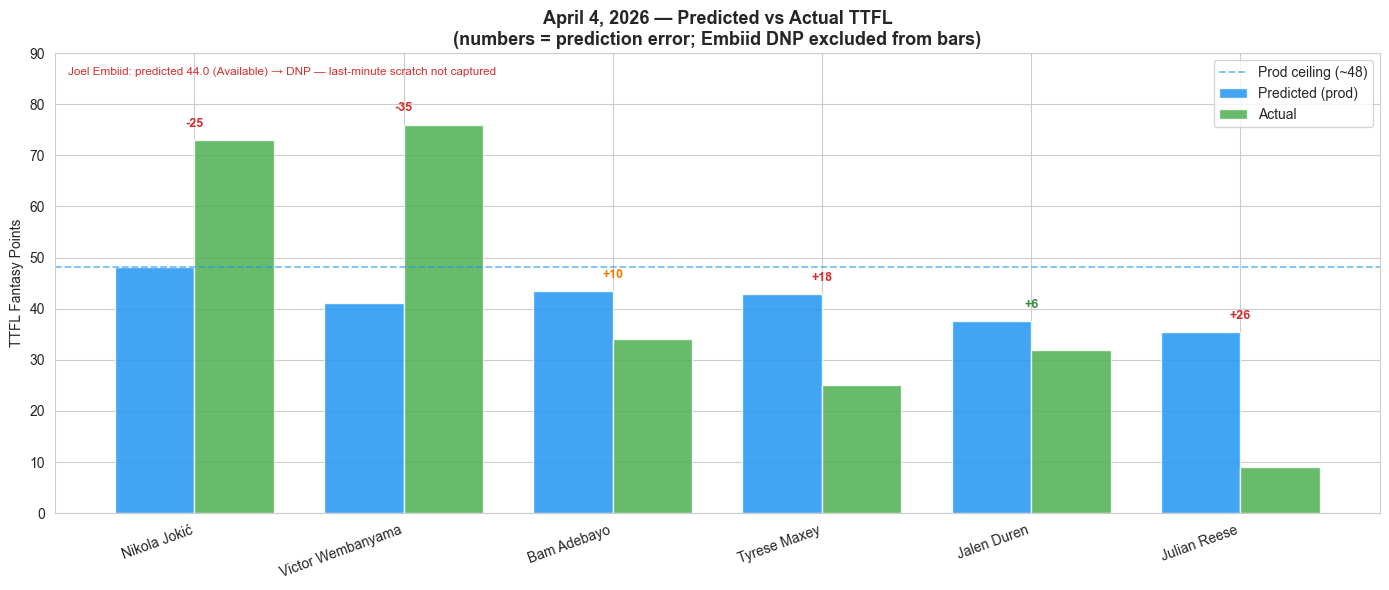

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Ground truth
actuals_apr4 = {
    'Nikola Joki\u0107': 73,
    'Victor Wembanyama': 76,
    'Joel Embiid': None,
    'Bam Adebayo': 34,
    'Tyrese Maxey': 25,
    'Jalen Duren': 32,
    'Julian Reese': 9,
}

# Production predictions
preds_prod = {
    'Nikola Joki\u0107': 48.2,
    'Victor Wembanyama': 41.2,
    'Joel Embiid': 44.0,
    'Bam Adebayo': 43.5,
    'Tyrese Maxey': 42.8,
    'Jalen Duren': 37.6,
    'Julian Reese': 35.4,
}

players_chart = [p for p, v in actuals_apr4.items() if v is not None]
actual_vals   = [actuals_apr4[p] for p in players_chart]
pred_vals     = [preds_prod[p]   for p in players_chart]

x     = np.arange(len(players_chart))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, pred_vals,   width, label='Predicted (prod)', color='#2196F3', alpha=0.85)
ax.bar(x + width/2, actual_vals, width, label='Actual',           color='#4CAF50', alpha=0.85)

# Annotate errors
for i, (p, a) in enumerate(zip(pred_vals, actual_vals)):
    err = p - a
    color = '#d32f2f' if abs(err) > 15 else '#f57c00' if abs(err) > 8 else '#388e3c'
    ax.text(i, max(p, a) + 2, f'{err:+.0f}', ha='center', va='bottom',
            fontsize=9, color=color, fontweight='bold')

# Ceiling reference
ax.axhline(48.2, color='#2196F3', linestyle='--', linewidth=1.3, alpha=0.6,
           label='Prod ceiling (~48)')

ax.set_xticks(x)
ax.set_xticklabels(players_chart, rotation=20, ha='right')
ax.set_ylabel('TTFL Fantasy Points')
ax.set_title(
    'April 4, 2026 — Predicted vs Actual TTFL\n'
    '(numbers = prediction error; Embiid DNP excluded from bars)',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='upper right')
ax.set_ylim(0, 90)
ax.text(0.01, 0.97,
        'Joel Embiid: predicted 44.0 (Available) → DNP — last-minute scratch not captured',
        transform=ax.transAxes, fontsize=8.5, color='#d32f2f', va='top')
plt.tight_layout()
plt.show()


In [17]:
# ── Error summary table ──────────────────────────────────────────────────
rows = []
for player in players_chart:
    pred   = preds_prod[player]
    actual = actuals_apr4[player]
    err    = pred - actual
    rows.append({
        'Player':     player,
        'Predicted':  pred,
        'Actual':     actual,
        'Error':      round(err, 1),
        'Abs Error':  round(abs(err), 1),
        'Direction':  'Under' if err < 0 else 'Over',
        'Root cause': (
            'Mean regression — elite ceiling' if err < -15 else
            'Role inflation (teammate out)' if player == 'Julian Reese' else
            'Mild overfit to recent form'
        )
    })

cmp = pd.DataFrame(rows).sort_values('Abs Error', ascending=False)
print(cmp.to_string(index=False))
print(f"\nMean Absolute Error (Apr 4, prod model): {cmp['Abs Error'].mean():.1f} TTFL pts")


           Player  Predicted  Actual  Error  Abs Error Direction                      Root cause
Victor Wembanyama       41.2      76  -34.8       34.8     Under Mean regression — elite ceiling
     Julian Reese       35.4       9   26.4       26.4      Over   Role inflation (teammate out)
     Nikola Jokić       48.2      73  -24.8       24.8     Under Mean regression — elite ceiling
     Tyrese Maxey       42.8      25   17.8       17.8      Over     Mild overfit to recent form
      Bam Adebayo       43.5      34    9.5        9.5      Over     Mild overfit to recent form
      Jalen Duren       37.6      32    5.6        5.6      Over     Mild overfit to recent form

Mean Absolute Error (Apr 4, prod model): 19.8 TTFL pts


## 11. Diagnose — Role Inflation: Julian Reese (predicted 35.4, actual 9)

Reese received starter-level minutes while Anthony Davis was absent.
The model extrapolated those minutes forward but had no signal that Davis would be active again.

**Trace:** look at Reese's minutes trend. A spike followed by a return to bench role
is the classic pattern the model mistakes for a stable new baseline.

**Fix candidates**
- `star_teammate_is_out` binary feature (team's top-minutes player unavailable)
- `minutes_rolling_trend` = minutes_rolling_3 - minutes_rolling_15 (detects temporary spikes)

In [18]:
# Trace Reese's recent minutes
from common.utils import parse_minutes

reese_candidates = players[
    players['player_last_name'].str.lower().str.contains('reese', na=False)
]
print("Reese candidates in players table:")
print(reese_candidates[['person_id', 'player_first_name', 'player_last_name']].to_string(index=False))


Reese candidates in players table:
 person_id player_first_name player_last_name
   1642882            Julian            Reese


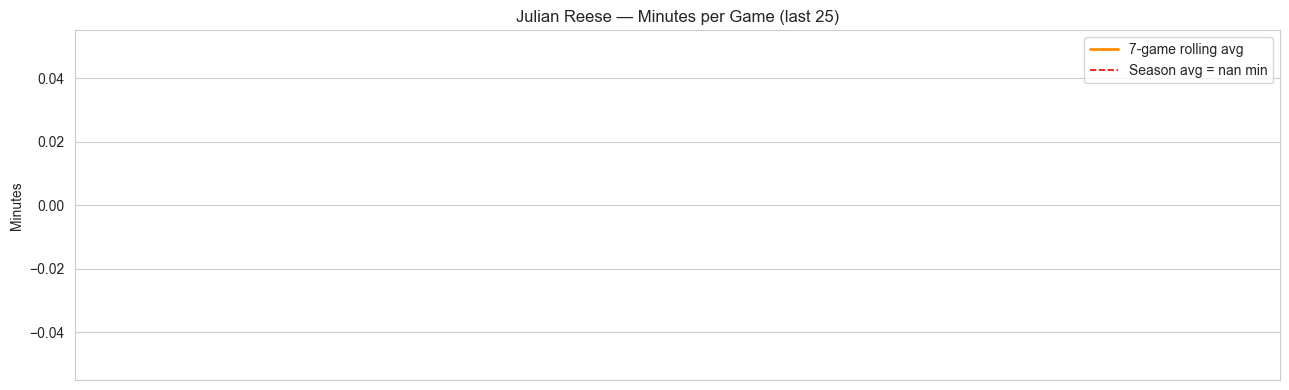

Rolling 3-game avg:  nan min
Rolling 15-game avg: nan min
→ If 3-game avg >> 15-game avg, the model sees a spike it mistakes for a new baseline.


In [19]:
# Replace with the person_id from above output
REESE_ID = reese_candidates['person_id'].iloc[0]

reese_games = box[box['personId'] == REESE_ID].copy()
reese_games['game_date'] = pd.to_datetime(reese_games['game_date'])
reese_games = reese_games.sort_values('game_date').tail(25)

if reese_games['minutes'].dtype == object:
    reese_games['minutes'] = reese_games['minutes'].apply(parse_minutes)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(len(reese_games)), reese_games['minutes'],
       color='steelblue', alpha=0.8)
avg_min = reese_games['minutes'].mean()
roll7   = reese_games['minutes'].rolling(7, min_periods=1).mean()
ax.plot(range(len(reese_games)), roll7, color='darkorange', lw=2, label='7-game rolling avg')
ax.axhline(avg_min, color='red', linestyle='--', lw=1.2,
           label=f'Season avg = {avg_min:.1f} min')
ax.set_xticks(range(len(reese_games)))
ax.set_xticklabels([str(d.date()) for d in reese_games['game_date']],
                    rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Minutes')
ax.set_title('Julian Reese — Minutes per Game (last 25)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Rolling 3-game avg:  {reese_games['minutes'].tail(3).mean():.1f} min")
print(f"Rolling 15-game avg: {reese_games['minutes'].tail(15).mean():.1f} min")
print("→ If 3-game avg >> 15-game avg, the model sees a spike it mistakes for a new baseline.")


In [20]:
# ── Prototype: minutes_rolling_trend feature ─────────────────────────────
df_trend = df.copy()
df_trend = df_trend.sort_values(['personId', 'game_date'])

# minutes_rolling_trend > 0 → player getting MORE minutes recently (temp spike)
# minutes_rolling_trend < 0 → player getting FEWER minutes (returning to bench)
df_trend['min_roll3']  = df_trend.groupby('personId')['minutes'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df_trend['min_roll15'] = df_trend.groupby('personId')['minutes'].transform(
    lambda x: x.shift(1).rolling(15, min_periods=1).mean())
df_trend['minutes_rolling_trend'] = df_trend['min_roll3'] - df_trend['min_roll15']

# Correlation: when trend is positive (minutes spike), does actual fantasy_points follow?
corr_trend = df_trend['minutes_rolling_trend'].corr(df_trend['fantasy_points'])
print(f"Correlation of minutes_rolling_trend with fantasy_points: {corr_trend:.3f}")
print("(Should be moderate-positive; if model over-weights it, it inflates predictions")
print(" for players mid-spike — exactly the Reese scenario)")


Correlation of minutes_rolling_trend with fantasy_points: 0.110
(Should be moderate-positive; if model over-weights it, it inflates predictions
 for players mid-spike — exactly the Reese scenario)


## 12. Summary — All Fixes & Deployment Checklist

| # | Issue | File / Location | Fix | Expected Impact |
|---|-------|----------------|-----|----------------|
| 1 | Engineering stats normalised by player minutes | `feature_engineering.py:203` | Apply per36/per_poss only to raw stats | Better matchup signal → –2–3 pts MAE |
| 2 | `possessions_per_poss` always 1.0 | `feature_engineering.py:208` | Skip possessions from per_poss norm | Remove 4 constant noise features |
| 3 | Encoder re-fit every inference | `feature_engineering.py:288`, `model_utils.py:238` | Serialise encoder in pkl, reuse at inference | Eliminate silent column misalignment |
| 4 | MSE objective → ~48 ceiling | `model_utils.py:116,150` | `objective='quantile', alpha=0.75` | Ceiling lifts to 60–70+, better top picks |
| 5 | Role inflation (no teammate context) | new feature | `minutes_rolling_trend` feature + `star_teammate_is_out` | Prevent Reese-type blow-ups |
| 6 | Availability stale (morning fetch only) | availability pipeline | Re-fetch at 5PM (game-day injury report) | Catch Embiid-type last-minute DNPs |

### Deployment steps
1. Update `normalize_features()` → separate raw vs engineering paths  
2. Update `get_feature_cols()` → use engineering stats raw  
3. Update `save_model_artifact()` + `load_model_artifact()` → include `encoder` key  
4. Update `encode_categorical_features()` → accept optional pre-fitted encoder  
5. Add `minutes_rolling_trend` to `key_stats_fantasy` (raw stat) in `constants.py`  
6. Update `DEFAULT_PARAMS['fantasy_points']` in `train.py` → `objective='quantile', alpha=0.75`  
7. Retrain model  
8. Validate on April 4 scenario (Section 10 of this notebook) before merging to master